<a href="https://colab.research.google.com/github/TejashwiniByrappa/Tejashwini-landing-page/blob/main/breast_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Breast Cancer Dataset generated successfully!
Dataset Shape: (1200, 8)
   Mean_Radius  Mean_Texture  Mean_Perimeter  Mean_Area  Mean_Smoothness  \
0        15.84         19.84           98.08     775.88           0.1031   
1        13.62         17.45           85.93     571.99           0.0952   
2        16.37         19.83          101.76     872.62           0.0765   
3        19.43         21.64          121.54    1186.04           0.0861   
4        13.28         19.51           86.79     565.78           0.0923   

   Mean_Concavity  Symmetry  Diagnosis  
0          0.0000    0.1848          1  
1          0.0382    0.1828          0  
2          0.0136    0.2030          0  
3          0.0447    0.1582          1  
4          0.0711    0.1339          0  


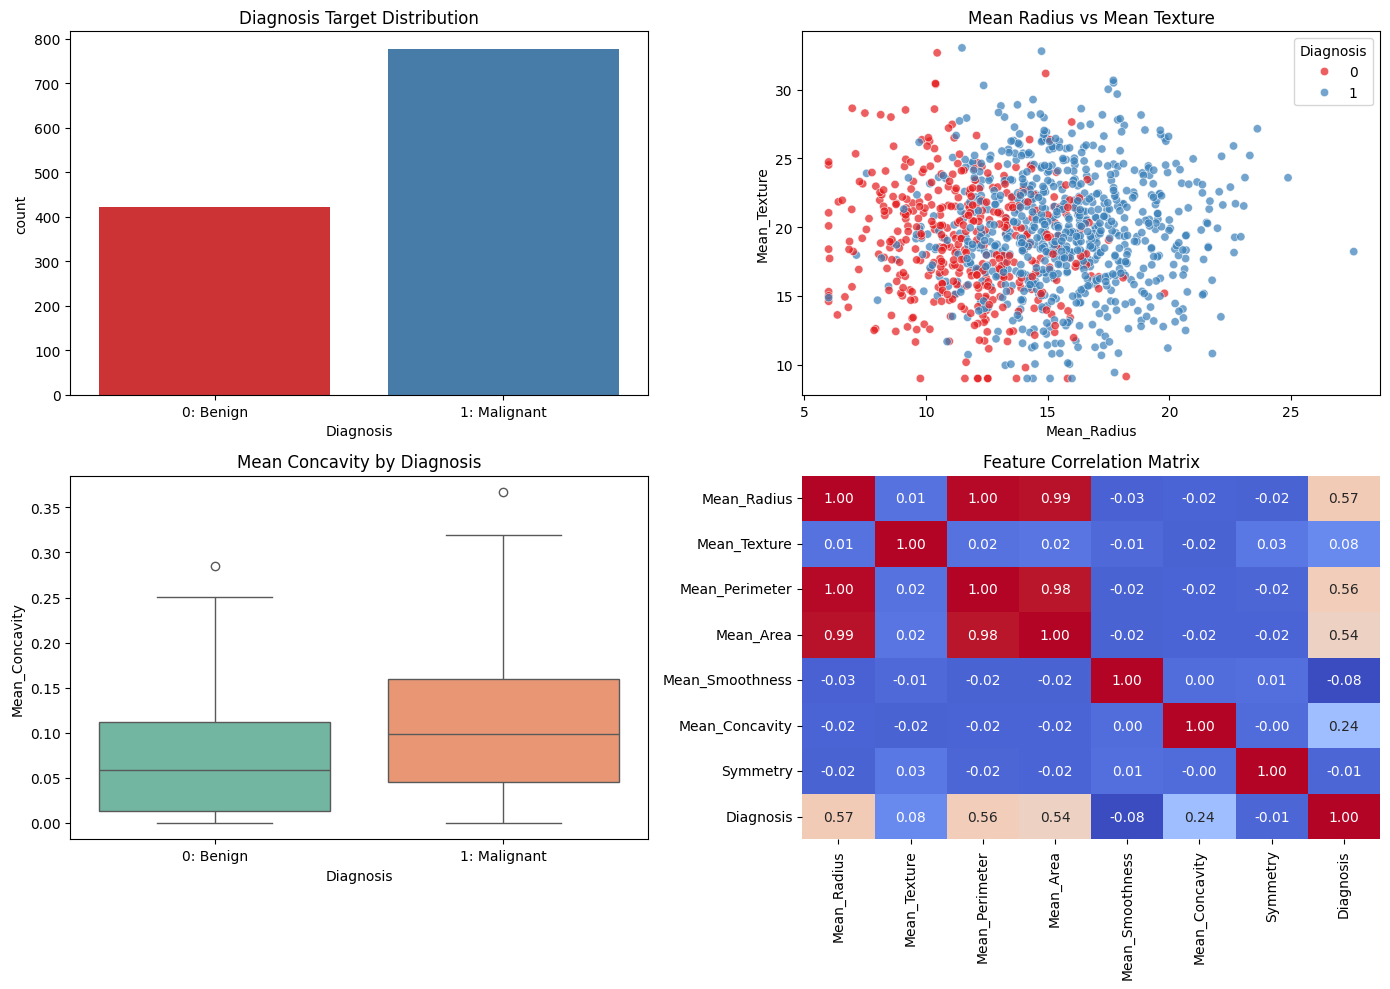

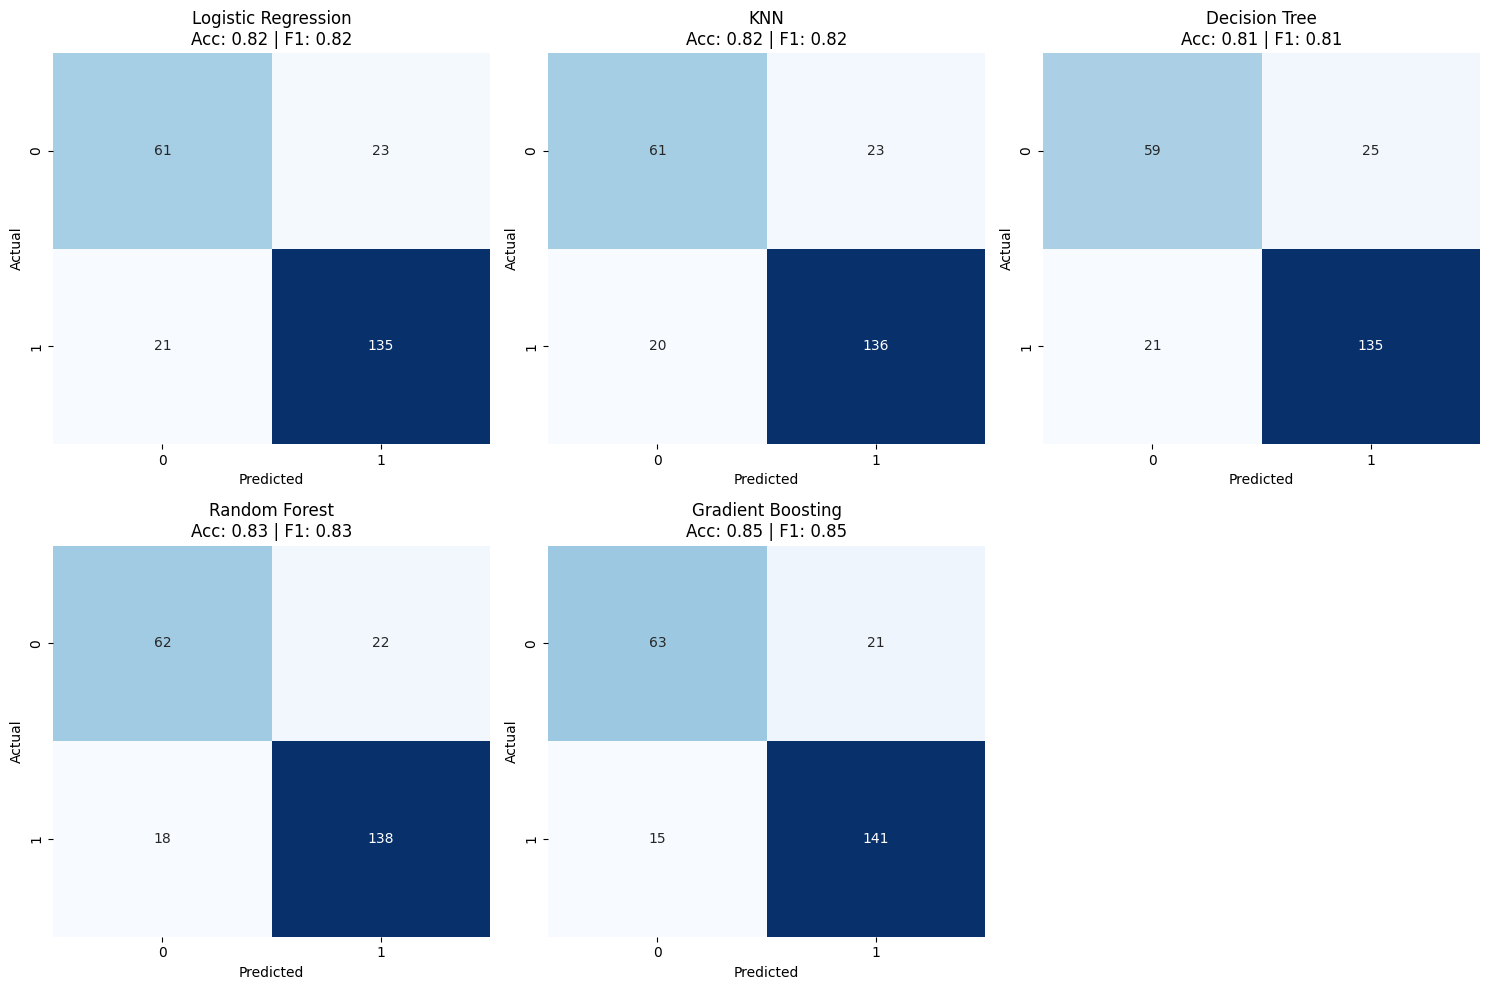

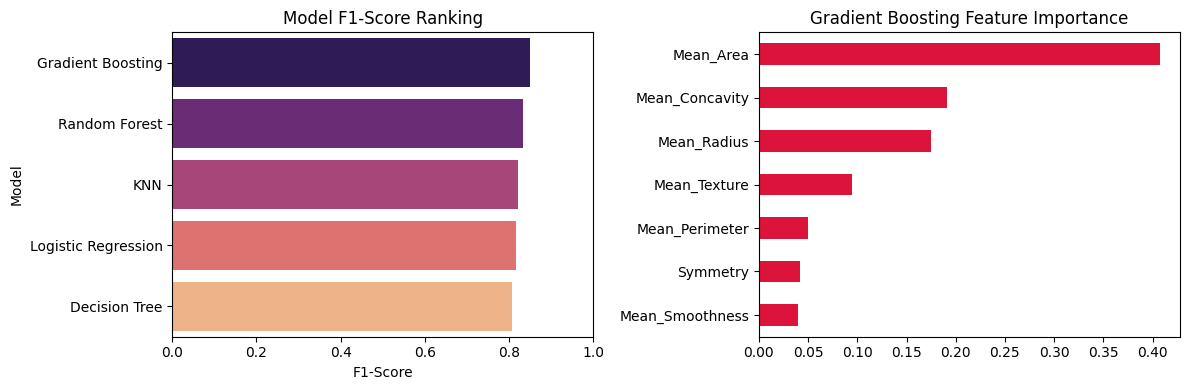


=== BREAST CANCER PREDICTION MODEL RANKING ===
              Model  Accuracy  F1-Score  Precision   Recall
  Gradient Boosting  0.850000  0.848637   0.870370 0.903846
      Random Forest  0.833333  0.832356   0.862500 0.884615
                KNN  0.820833  0.820058   0.855346 0.871795
Logistic Regression  0.816667  0.816146   0.854430 0.865385
      Decision Tree  0.808333  0.807209   0.843750 0.865385


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

warnings.simplefilter(action='ignore', category=FutureWarning)

# ==========================================
# 1. GENERATE SYNTHETIC BREAST CANCER DATASET
# ==========================================
np.random.seed(42)
n_samples = 1200

# Feature Generation (Modeled after Wisconsin Breast Cancer Dataset)
mean_radius = np.random.normal(14.1, 3.5, n_samples).clip(6.0, 30.0).round(2)
mean_texture = np.random.normal(19.3, 4.3, n_samples).clip(9.0, 40.0).round(2)
mean_perimeter = (2 * np.pi * mean_radius + np.random.normal(0, 2, n_samples)).round(2)
mean_area = (np.pi * (mean_radius ** 2) + np.random.normal(0, 15, n_samples)).clip(100.0, 2500.0).round(2)
mean_smoothness = np.random.normal(0.096, 0.014, n_samples).clip(0.05, 0.16).round(4)
mean_concavity = np.random.normal(0.088, 0.079, n_samples).clip(0.0, 0.45).round(4)
symmetry = np.random.normal(0.181, 0.027, n_samples).clip(0.1, 0.3).round(4)

# Malignant Probability (1 = Malignant, 0 = Benign) driven by radius, area, and concavity
malignant_prob = 1 / (1 + np.exp(-(
    -8.5
    + 0.35 * mean_radius
    + 0.08 * mean_texture
    + 0.003 * mean_area
    + 12.0 * mean_concavity
)))
diagnosis = np.random.binomial(1, malignant_prob)

df = pd.DataFrame({
    'Mean_Radius': mean_radius,
    'Mean_Texture': mean_texture,
    'Mean_Perimeter': mean_perimeter,
    'Mean_Area': mean_area,
    'Mean_Smoothness': mean_smoothness,
    'Mean_Concavity': mean_concavity,
    'Symmetry': symmetry,
    'Diagnosis': diagnosis
})

print("Breast Cancer Dataset generated successfully!")
print(f"Dataset Shape: {df.shape}")
print(df.head())


# ==========================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
plt.figure(figsize=(14, 10))

# Graph 1: Diagnosis Class Distribution
plt.subplot(2, 2, 1)
sns.countplot(x="Diagnosis", data=df, hue="Diagnosis", palette="Set1", legend=False)
plt.xticks(ticks=[0, 1], labels=['0: Benign', '1: Malignant'])
plt.title("Diagnosis Target Distribution")

# Graph 2: Mean Radius vs Mean Texture by Diagnosis
plt.subplot(2, 2, 2)
sns.scatterplot(x="Mean_Radius", y="Mean_Texture", data=df, hue="Diagnosis", palette="Set1", alpha=0.7)
plt.title("Mean Radius vs Mean Texture")

# Graph 3: Mean Concavity Distribution by Diagnosis
plt.subplot(2, 2, 3)
sns.boxplot(x="Diagnosis", y="Mean_Concavity", data=df, hue="Diagnosis", palette="Set2", legend=False)
plt.xticks(ticks=[0, 1], labels=['0: Benign', '1: Malignant'])
plt.title("Mean Concavity by Diagnosis")

# Graph 4: Feature Correlation Heatmap
plt.subplot(2, 2, 4)
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=False)
plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()


# ==========================================
# 3. PREPROCESSING & SPLITTING
# ==========================================
X = df.drop(columns=["Diagnosis"])
y = df["Diagnosis"]

# Train-Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ==========================================
# 4. MODEL TRAINING & CLASSIFICATION EVALUATION
# ==========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-Score": f1,
        "Precision": prec,
        "Recall": rec
    })

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx], cbar=False)
    axes[idx].set_title(f"{name}\nAcc: {acc:.2f} | F1: {f1:.2f}")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

axes[5].axis("off")
plt.tight_layout()
plt.show()


# ==========================================
# 5. MODEL RANKING & FEATURE IMPORTANCE
# ==========================================
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)

plt.figure(figsize=(12, 4))

# Chart 1: F1-Score Comparison
plt.subplot(1, 2, 1)
sns.barplot(x="F1-Score", y="Model", data=results_df, hue="Model", palette="magma", legend=False)
plt.title("Model F1-Score Ranking")
plt.xlim(0, 1)

# Chart 2: Feature Importance from Gradient Boosting
gb_model = models["Gradient Boosting"]
importances = pd.Series(gb_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.subplot(1, 2, 2)
importances.plot(kind="barh", color="crimson")
plt.title("Gradient Boosting Feature Importance")

plt.tight_layout()
plt.show()

print("\n=== BREAST CANCER PREDICTION MODEL RANKING ===")
print(results_df.to_string(index=False))